# Zonal statistics

Summarise raster values **within each vector polygon** — the classic "average elevation per
watershed" operation. `ds.zonal_stats(polygons, stats=(...))` returns a table with one row
per polygon and one column per requested statistic.

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-ops-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

ds = Dataset.read_file(DATA / 'acc4000.tif')
zones = FeatureCollection.read_file(DATA / 'coello_polygons.geojson')
len(zones), zones.epsg

(4, 32618)

Plot the inputs: the raster band to be summarised and the polygon zones laid over the same area.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


<Axes: >

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


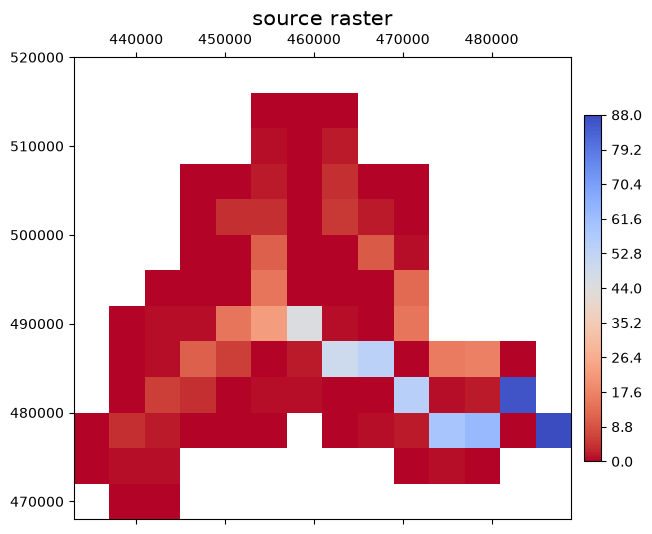

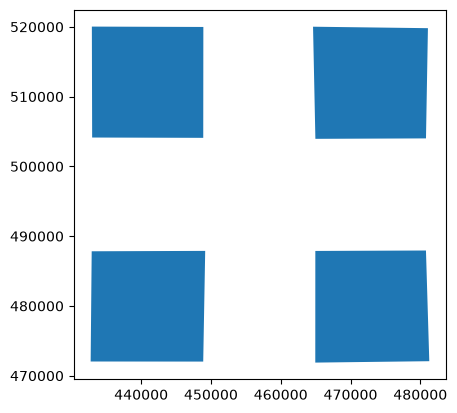

In [3]:
ds.plot(band=0, title='source raster')
zones.plot()

## Compute per-zone statistics

Each polygon is rasterised onto the raster grid, then the covered cells are reduced.

In [4]:
stats = ds.zonal_stats(zones, stats=('mean', 'min', 'max', 'sum', 'count'))
stats

,mean,min,max,sum,count
0,0.000000,0.0,0.0,0.0,1.0
1,0.000000,0.0,0.0,0.0,2.0
2,2.307692,0.0,11.0,30.0,13.0
3,18.066667,0.0,63.0,271.0,15.0


Join the per-zone `mean` back onto the polygons and plot — a choropleth of the zonal average.

<Axes: >

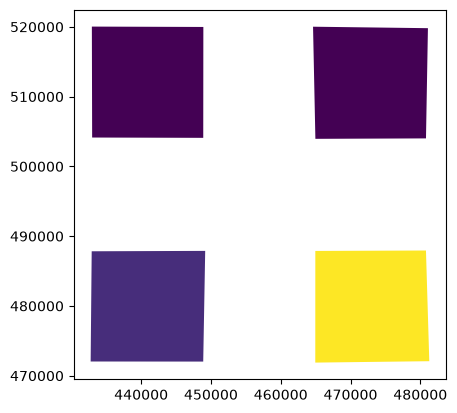

In [5]:
zones['mean'] = stats['mean'].to_numpy()
zones.plot(column='mean')

## Notes

- `band=` selects which band to summarise (default 0).
- The polygons may be in any CRS — they are reprojected to the raster's CRS internally.
- See also: [Crop & mask](crop-mask.ipynb), [Extract at points](extract-at-points.ipynb).